# Carga de datos

In [2]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parents[0]))
from scripts.data.load_data import cargar_raw
df=cargar_raw("titanic_dataset.csv")
df.head()

#print(Path(__file__).resolve().parents) Usar cuando necesite conocer la ruta de un archivo.

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Visión general de dataset


In [3]:
df.shape

(891, 12)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
df.memory_usage().sum()

85668

In [6]:
df.duplicated().sum()

0

In [7]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [8]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [9]:
df.nunique()

PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          147
Embarked         3
dtype: int64

In [10]:
import pandas as pd

porcentaje_nulos= pd.DataFrame({
    "Nulos": df.isna().sum(),
    "Porcentaje": df.isna().sum()/len(df)*100
}).sort_values("Porcentaje", ascending=False)

porcentaje_nulos.round(2)

,Nulos,Porcentaje
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22
PassengerId,0,0.00
Survived,0,0.00
Pclass,0,0.00
Name,0,0.00
Sex,0,0.00
SibSp,0,0.00
Parch,0,0.00


In [11]:
ratio_unicos= pd.DataFrame({
    "Unicos": df.nunique(),
    "Ratio": df.nunique()/len(df)
})

ratio_unicos.round(2)

,Unicos,Ratio
PassengerId,891,1.00
Survived,2,0.00
Pclass,3,0.00
Name,891,1.00
Sex,2,0.00
Age,88,0.10
SibSp,7,0.01
Parch,7,0.01
Ticket,681,0.76
Fare,248,0.28


# Análisis por variable

## Validación

In [40]:
# Importar librerías para visualizar

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#PassengerId validación

resumen_passenger_id = pd.Series({
    "tipo": df["PassengerId"].dtype,
    "duplicados": df["PassengerId"].duplicated().sum(),
    "nulos": df["PassengerId"].isna().sum(),
    "max": df["PassengerId"].max(),
    "min": df["PassengerId"].min(),
    "longitud": df["PassengerId"].astype(str).str.len().value_counts()
})

resumen_passenger_id

tipo                                                      int64
duplicados                                                    0
nulos                                                         0
max                                                         891
min                                                           1
longitud      PassengerId
3    792
2     90
1      9
Name: c...
dtype: object

In [36]:
#Convertir PassengerId a string

df["PassengerId"] = df["PassengerId"].astype(str)
df["PassengerId"].dtype

dtype('O')

In [39]:
# Survived validación

resumen_survived = pd.Series({
    "tipo": df["Survived"].dtype,
    "nulos": df["Survived"].isna().sum(),
    "valores unicos": df["Survived"].unique(),
    "conteo valores unicos": df["Survived"].value_counts()
})

resumen_survived

tipo                                                                 int64
nulos                                                                    0
valores unicos                                                      [0, 1]
conteo valores unicos    Survived
0    549
1    342
Name: count, dtype:...
dtype: object

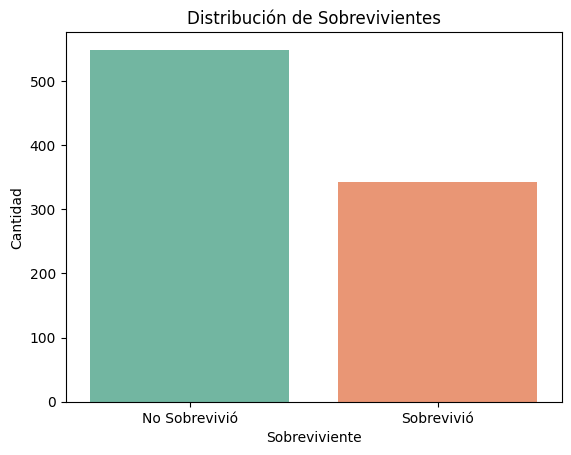

Survived
0    62.0
1    38.0
Name: proportion, dtype: float64

In [61]:
# Visualización de Survived

sobrevivientes = df['Survived'].value_counts(normalize=True)

sns.countplot(
    data=df,
    x='Survived',
    palette='Set2')

plt.title('Distribución de Sobrevivientes')
plt.xlabel('Sobreviviente')
plt.ylabel('Cantidad')
plt.xticks(ticks=[0, 1], labels=['No Sobrevivió', 'Sobrevivió'])
plt.show()

round(sobrevivientes, 2)*100



In [ ]:
# Variables categoricas sex embarked y Pclass validación